In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd '/content/drive/My Drive/Grad School/Thesis/RL Experiments/MiniBlackJack/Theorem_2_Experiments'

/content/drive/My Drive/Grad School/Thesis/RL Experiments/MiniBlackJack/Theorem_2_Experiments


In [ ]:
!pwd

/content/drive/My Drive/Grad School/Thesis/RL Experiments/MiniBlackJack/Theorem_2_Experiments


In [ ]:
import Cards
import Policy
import Agent
from Expected_Value_Helper import calculate_expected_reward, expected_val_deriv

import torch
import numpy as np
import math
import matplotlib.pyplot as plt


In [ ]:
if torch.cuda.is_available():
  print("Using cuda GPU")
  torch.set_default_device("cuda")

Using cuda GPU


Game Parameters

In [ ]:
# Set seed for reproducibility
seed = 42
torch.manual_seed(seed)

In [ ]:
# Initialize the game parameters
max_card = 5 # Largest value of card in play
max_hand_value = 10 # The Blackjack number
min_hand_value = 2 # Minimum possible starting hand value
state_space = (max_hand_value - min_hand_value + 1 , max_card) # Decision space of the agent

Construct aperiodic, irreducible, time-homogeneous Markov Chain

In [ ]:
number_of_states = state_space[0] * state_space[1]
P = torch.zeros( (number_of_states,  number_of_states) )
diagonal_entries = torch.rand(number_of_states)
diagonal_entries = torch.where(diagonal_entries == 0 , 0.1 , diagonal_entries)

for i in range(number_of_states):
  P[i,i] = diagonal_entries[i].item()

  if (i+1) < number_of_states:
    P[i,i+1] = 1 - diagonal_entries[i].item()
  else: # Loop back around when filling the adjacent column of the matrix
    P[i,0] = 1 - diagonal_entries[i].item()

del i

# Because every state in the above matrix has a self loop then it is aperiodic
# Because every state can reach the adjacent state, then it is irreducible.

Calculate Markov Chain Stationary Distribution

In [ ]:
stationary_distribution = P.clone()
for i in range(100000):
  stationary_distribution = torch.matmul(P, stationary_distribution)
del i

In [ ]:
stationary_distribution

tensor([[0.0115, 0.0045, 0.0074,  ..., 0.3006, 0.0084, 0.0559],
        [0.0115, 0.0045, 0.0074,  ..., 0.3006, 0.0084, 0.0559],
        [0.0115, 0.0045, 0.0074,  ..., 0.3006, 0.0084, 0.0559],
        ...,
        [0.0115, 0.0045, 0.0074,  ..., 0.3006, 0.0084, 0.0559],
        [0.0115, 0.0045, 0.0074,  ..., 0.3006, 0.0084, 0.0559],
        [0.0115, 0.0045, 0.0074,  ..., 0.3006, 0.0084, 0.0559]],
       device='cuda:0')

Create Look-up Table to associate an integer with the game state i.e. (total player hand, visible dealer card)

In [ ]:
state_look_up_table= {}

chain_state_index = 0
for card_num in range(1,max_card+1):
  for player_hand in range(2,max_hand_value+1):
      # Encode the state space (player hand sum, dealer visible card) with integers (to used to index the transition matrix)
      state_look_up_table[chain_state_index] = (player_hand , card_num)
      chain_state_index += 1

inverse_lookup_table = {v: k for k, v in state_look_up_table.items()}

Simulation

In [ ]:
# Initialize the SIGD parameters here
theta = 0.5 # Gradient error decrease (0,1)
mu = 2.5 # Error scaling factor > 1 (strictly greater than two to bound by function norms)

# Initialize line search parameters here
e_f = 2 # Bound on the noise between F and E[F]
tau = 0.5 # Backtacking factor (0,1]
c_1 = 0.5 # Armijo parameter (0,1)

# Lipschitz constant (we use that of the gradient of the sigmoid, though in reality the Lipschitz constant is probably larger than this)
L_lip = 0.25

# Number of time we will independently run the algorithm
number_experiment_replications = 1
# Number of training steps in a single replication
epoch_num = 20000
# For all the replication, save the values of x_k for each iteration of the Algorithm
x_k_params_through_training = torch.zeros((number_experiment_replications , epoch_num , state_space[0], state_space[1] ))


step_exponent = 0.501
step_sizes = [1.0 / (k ** step_exponent) for k in range(1,epoch_num+1)]
step_sizes = torch.tensor(step_sizes)
natural_log = [math.log(k) for k in range(1,epoch_num+1)]
natural_log = torch.tensor(natural_log)
alphas = natural_log * natural_log  * step_sizes

In [ ]:
gradient_norm_tracker = torch.zeros((number_experiment_replications, epoch_num))

In [ ]:
# Start a new experiment replication (meaning a new run of the Algorithm)
for rep in range(number_experiment_replications):
      # Create the player agent
      player_agent = Agent.Agent(Policy = Policy.Player_Policy, state_space_shape=state_space)
      # Initialize the training parameters for this experiment run
      x_k = torch.zeros(state_space, dtype=torch.float64)
      # x_k = torch.empty(state_space, dtype=torch.float64) #torch.zeros(state_space, dtype=torch.float64)
      # torch.nn.init.xavier_normal_(x_k)
      player_agent.update_params(x_k.clone())
      eps_k = 100.0 # reset eps_k for the replication


      state = torch.randint(low=0, high=len(state_look_up_table), size=(1,)).item()

      # Start the training loop
      for k in range(epoch_num):
              if k % 100 == 0 : print(f"rep= {rep} , iteration = {k}")

              # # Walk along the Markov Chain
              prob_stay = P[state, state].item()
              stay_flag = torch.bernoulli(input = torch.tensor(prob_stay)).item()
              if(stay_flag == 0): # Move to the next state and update the starting state of the game
                state = (state + 1) % P.shape[0]
                #print(f"State has change to state: {state} at traning iteration: {k}")

              # ###### DETERMINE INITIAL STARTING STATE OF THE BLACKJACK GAME FOR THIS TRAINING STEP #######
              intial_game_state = state_look_up_table[state] # Card player hand sum, visible dealer card
              dealer_hidden_card = Cards.draw_cards(num_draws=1, num_sims=1, max_card=max_card)
              dealer_cards = torch.tensor([intial_game_state[1] , dealer_hidden_card[0].item()])


              # Simulate draws
              draws = Cards.draw_cards(num_draws = 10, # We never need to draw more than 10 times per simulation
                              num_sims = 10000, # Simulations we will conduct
                              max_card = max_card)

              sums = Cards.partial_sums(draws) # Partial sums of simulated draws


              # Calculate expected valued under current policy
              actions, player_hands, not_busted_filter = player_agent.apply_Policy(init_state_space=intial_game_state,
                                                                  partial_sums=sums,
                                                                  policy_probabilities=player_agent.get_probabilities(),
                                                                  max_hand_value=max_hand_value)

              reward_per_sim = Agent.calculate_reward(actions = actions,
                                      player_hands = player_hands,
                                      not_busted_filter = not_busted_filter,
                                      dealer_total_hand = dealer_cards.sum().item(),
                                      max_hand_value = max_hand_value)

              expected_value = reward_per_sim.to(torch.float64).mean().item()


              #--------- Inexact Gradient Step #-------------
              i = 0
              # Recalculate gradient error and required distance before the next training iteration
              gradient_error = (theta ** i) * eps_k
              distance = 0.99 * (2*gradient_error)/(L_lip * (x_k.numel() ** 0.5))
              g_k = torch.zeros_like(x_k)

              while (True):
                  # Calculate gradient using forward finite difference by
                  # calculating the new expected value under the shifted policy
                  rows = x_k.shape[0]
                  cols = x_k.shape[1]
                  for n in range(rows):
                      for m in range(cols):
                          # Single parameter of x_k we will shift
                          shifted_x_k = x_k.clone()
                          shifted_x_k[n,m] = x_k[n,m] + distance

                          # Calculate the new expected value under the shifted policy
                          actions, player_hands, not_busted_filter = player_agent.apply_Policy(init_state_space=intial_game_state,
                                                partial_sums=sums,
                                                policy_probabilities=player_agent.get_probabilities(alternative_params=shifted_x_k),
                                                max_hand_value=max_hand_value)

                          alt_reward_per_sim = Agent.calculate_reward(actions = actions,
                                              player_hands = player_hands,
                                              not_busted_filter = not_busted_filter,
                                              dealer_total_hand = dealer_cards.sum().item(),
                                              max_hand_value = max_hand_value)

                          changed_expected_value = alt_reward_per_sim.to(torch.float64).mean().item()

                          # Take forward finite difference and estimate value of the gradient
                          g_k[n,m] = (changed_expected_value  - expected_value)/distance

                  d_k = 1 * g_k # Descent Direction (when positive we try and win, when negative we try to learn to lose)

                   # Check if gradient norm is large enough or if we have violated the assumption of zero-gradient (this could also be a numerical issue as well)
                  if ((torch.linalg.norm(g_k).item() > gradient_error * mu ) or (torch.linalg.norm(g_k).item() < 1e-30)):
                      # Calculate step-size
                        if True:
                          x_k = x_k + step_sizes[k].item() * d_k #(g_k * (state_space[0] * state_space[1] * stationary_distribution[state, state].item())) # Update the paramter
                          if(torch.linalg.norm(g_k).item() < 1e-30):
                            pass # Bad iteration --> don't update eps_k
                          else:
                            eps_k = (theta ** i) * eps_k # Update error parameter now that we successfuly decreased
                        else:
                          pass
                          # x_k = x_k --> Decrease condition not meant, parameter is not updated
                        gradient_norm_tracker[rep,k] = torch.linalg.norm( g_k.detach().clone() )

                        # Step 2: Update
                        x_k_params_through_training[rep,k] = x_k.detach().clone() # Save the trainable parameter for this repetition and iteration
                        player_agent.update_params(x_k) # Update the internal value of the player agent for the new parameter

                        break # End the while loop
                  else:
                        i += 1
                        gradient_error = (theta ** i) * eps_k
                        distance = 0.99 * (2*gradient_error)/(L_lip * (x_k.numel() ** 0.5))





rep= 0 , iteration = 0
rep= 0 , iteration = 100
rep= 0 , iteration = 200
rep= 0 , iteration = 300
rep= 0 , iteration = 400
rep= 0 , iteration = 500
rep= 0 , iteration = 600
rep= 0 , iteration = 700
rep= 0 , iteration = 800
rep= 0 , iteration = 900
rep= 0 , iteration = 1000
rep= 0 , iteration = 1100
rep= 0 , iteration = 1200
rep= 0 , iteration = 1300
rep= 0 , iteration = 1400
rep= 0 , iteration = 1500
rep= 0 , iteration = 1600
rep= 0 , iteration = 1700
rep= 0 , iteration = 1800
rep= 0 , iteration = 1900
rep= 0 , iteration = 2000
rep= 0 , iteration = 2100
rep= 0 , iteration = 2200
rep= 0 , iteration = 2300
rep= 0 , iteration = 2400
rep= 0 , iteration = 2500
rep= 0 , iteration = 2600
rep= 0 , iteration = 2700
rep= 0 , iteration = 2800
rep= 0 , iteration = 2900
rep= 0 , iteration = 3000
rep= 0 , iteration = 3100
rep= 0 , iteration = 3200
rep= 0 , iteration = 3300
rep= 0 , iteration = 3400
rep= 0 , iteration = 3500
rep= 0 , iteration = 3600
rep= 0 , iteration = 3700
rep= 0 , iteration = 380

In [ ]:
# Create the player agent
agent = Agent.Agent(Policy = Policy.Player_Policy, state_space_shape=state_space)
n_sims =  10000 # Simulations we will conduct

# Simulate draws
# DO THIS AHEAD OF TIME TO REDUCE COMPUTATIONAL COST
# HAVE LARGE NUMBER OF SIMS FOR ACCURACY
draws = Cards.draw_cards(num_draws = 10, # We never need to draw more than 10 times per simulation
                num_sims = n_sims, # Simulations we will conduct
                max_card = max_card)

sums = Cards.partial_sums(draws) # Partial sums of simulated draws

expected = []

for k in range(0,epoch_num ,100):
        average_expected_value_over_starts = 0
        rep=0
        print(f"replication: {rep}, iteration: {k}")
        param_x_k = x_k_params_through_training[rep,k]

        for state in state_look_up_table.keys():
                  start_state = state_look_up_table[state]
                  intial_game_state = state_look_up_table[state] # Card player hand sum, visible dealer card

                  # Go through all of the possible hidden dealer cards
                  for d_2 in [1,2,3,4,5]:
                        dealer_cards = torch.tensor([intial_game_state[1] , d_2])

                        actions, player_hands, not_busted_filter = player_agent.apply_Policy(init_state_space=intial_game_state,
                                                                        partial_sums=sums,
                                                                        policy_probabilities=player_agent.get_probabilities(alternative_params=param_x_k),
                                                                        max_hand_value=max_hand_value)

                        reward_per_sim = Agent.calculate_reward(actions = actions,
                                            player_hands = player_hands,
                                            not_busted_filter = not_busted_filter,
                                            dealer_total_hand = dealer_cards.sum().item(),
                                            max_hand_value = max_hand_value)

                        expected_value = reward_per_sim.to(torch.float64).mean().item()
                        average_expected_value_over_starts += expected_value * stationary_distribution[state,state] * (1/5)

        expected.append(average_expected_value_over_starts.item())

        # OLD CODE --> DO NOT USE
        #  for player_card_1 in [1,2,3,4,5]:
        #    for player_card_2 in [1,2,3,4,5]:
        #      for d_1 in [1,2,3,4,5]:
        #        for d_2 in [1,2,3,4,5]:

        #           ###### DETERMINE INITIAL STARTING STATE ########
        #           # Deal the initial cards needed for the initial state
        #           dealer_cards = torch.tensor([[d_1,d_2]]) # [1,2] tensor
        #           visible_dealer_card = dealer_cards[0,0] # only show first card
        #           # Deal the initial cards needed for the first simulation
        #           start_hand = player_card_1 + player_card_2
        #           intial_game_state = (start_hand , visible_dealer_card.item())

        #           state = inverse_lookup_table[intial_game_state]

        #           # Estimate the gradient for this x_k
        #           ## Calculate expected valued under current policy
        #           actions, player_hands, not_busted_filter = player_agent.apply_Policy(init_state_space=intial_game_state,
        #                                                           partial_sums=sums,
        #                                                           policy_probabilities=player_agent.get_probabilities(alternative_params=param_x_k),
        #                                                           max_hand_value=max_hand_value)

        #           reward_per_sim = Agent.calculate_reward(actions = actions,
        #                               player_hands = player_hands,
        #                               not_busted_filter = not_busted_filter,
        #                               dealer_total_hand = dealer_cards.sum().item(),
        #                               max_hand_value = max_hand_value)

        #           expected_value = reward_per_sim.to(torch.float64).mean().item()

        #           average_expected_value_over_starts += expected_value * stationary_distribution[state,state] * (1/5)

        #           if start_hand == 10 and d_1 == 5 and d_2 ==5: expected.append(average_expected_value_over_starts.item())



replication: 0, iteration: 0
replication: 0, iteration: 100
replication: 0, iteration: 200
replication: 0, iteration: 300
replication: 0, iteration: 400
replication: 0, iteration: 500
replication: 0, iteration: 600
replication: 0, iteration: 700
replication: 0, iteration: 800
replication: 0, iteration: 900
replication: 0, iteration: 1000
replication: 0, iteration: 1100
replication: 0, iteration: 1200
replication: 0, iteration: 1300
replication: 0, iteration: 1400
replication: 0, iteration: 1500
replication: 0, iteration: 1600
replication: 0, iteration: 1700
replication: 0, iteration: 1800
replication: 0, iteration: 1900
replication: 0, iteration: 2000
replication: 0, iteration: 2100
replication: 0, iteration: 2200
replication: 0, iteration: 2300
replication: 0, iteration: 2400
replication: 0, iteration: 2500
replication: 0, iteration: 2600
replication: 0, iteration: 2700
replication: 0, iteration: 2800
replication: 0, iteration: 2900
replication: 0, iteration: 3000
replication: 0, iter

In [ ]:
10000-100


9900

In [ ]:
20000-100

19900

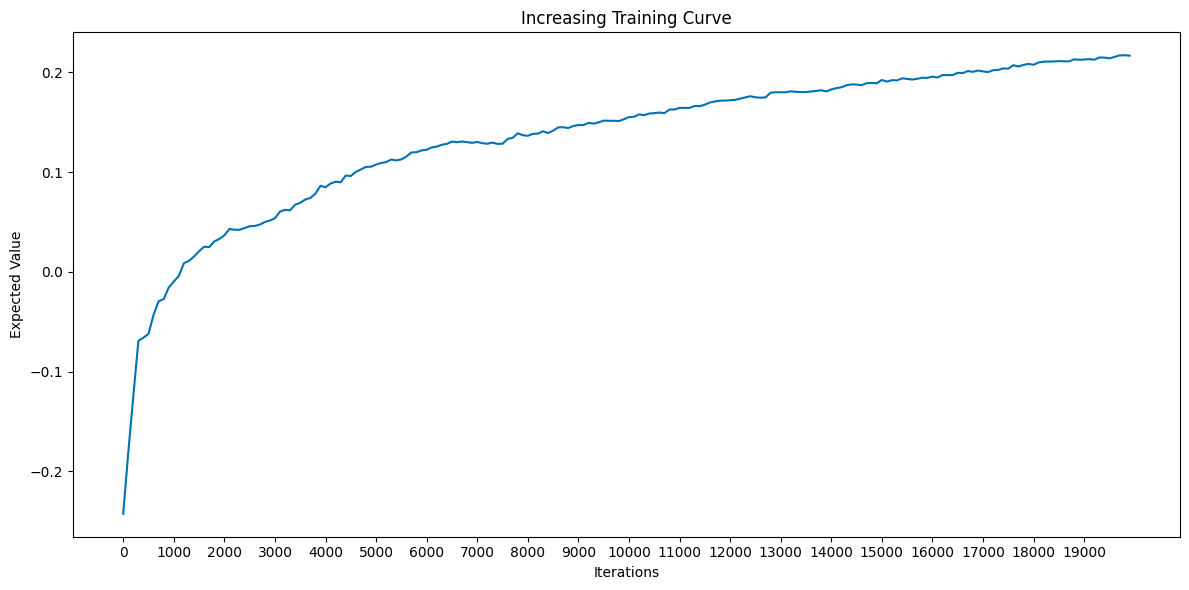

In [ ]:
plt.style.use('seaborn-v0_8-colorblind')
# Create the figure to set the plot
plt.figure(figsize=(12, 6))
# Extract the values to be plotted
plt.plot(expected)
plt.xticks(range(0,len(expected),10), labels=list(range(0, epoch_num, 1000)))
plt.title("Increasing Training Curve")
plt.xlabel("Iterations") # Always automatically generate
plt.ylabel("Expected Value")
plt.tight_layout() # Ensure the correct before saving
plt.show()

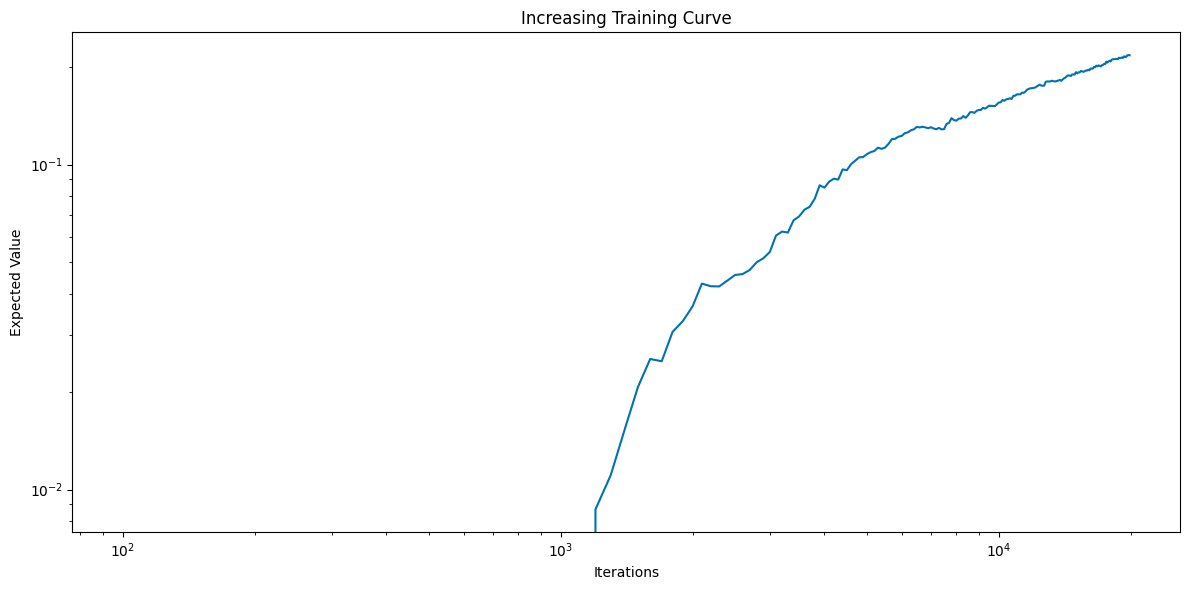

In [ ]:
plt.style.use('seaborn-v0_8-colorblind')
# Create the figure to set the plot
plt.figure(figsize=(12, 6))
#plt.figure()
# Extract the values to be plotted
plt.loglog(np.arange(1, len(expected) + 1) * 100 - 100 , expected)
plt.title("Increasing Training Curve")
plt.xlabel("Iterations") # Always automatically generate
plt.ylabel("Expected Value")
plt.tight_layout() # Ensure the correct before saving
plt.show()

In [ ]:
torch.sigmoid(x_k_params_through_training[0, epoch_num-100])

tensor([[0.7380, 0.5733, 0.6641, 0.5716, 0.4745],
        [0.5768, 0.6481, 0.5029, 0.9198, 0.5133],
        [0.7308, 0.8944, 0.4704, 0.6965, 0.4354],
        [0.5108, 0.7639, 0.8130, 0.7143, 0.8463],
        [0.2586, 0.2447, 0.6983, 0.6198, 0.6508],
        [0.1157, 0.2224, 0.1902, 0.3720, 0.5020],
        [0.0928, 0.1773, 0.1822, 0.2174, 0.0277],
        [0.2735, 0.0662, 0.1224, 0.1634, 0.2331],
        [0.0894, 0.1218, 0.0942, 0.0639, 0.0357]], device='cuda:0')

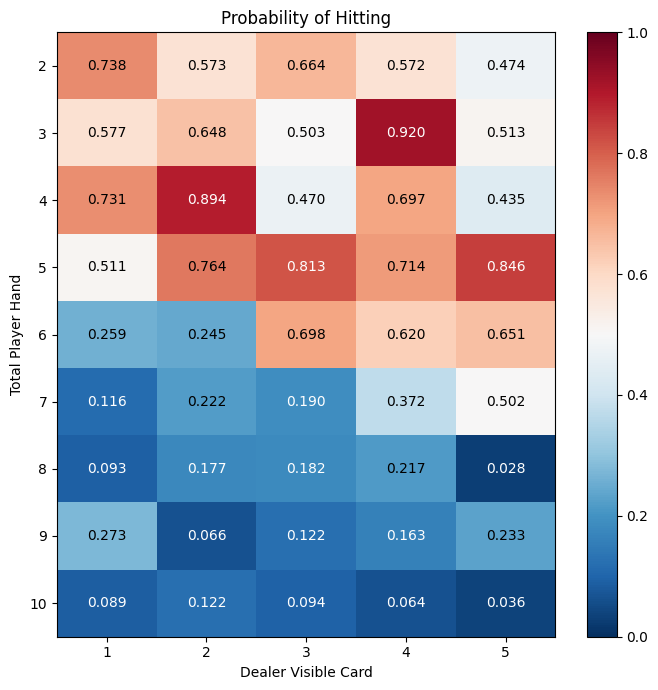

In [ ]:
heat_map_data = torch.sigmoid(x_k_params_through_training[0, epoch_num-100]).detach().cpu().numpy()

plt.figure(figsize=(7,7))
plt.imshow(heat_map_data, cmap="RdBu_r", vmin=0, vmax=1, aspect='auto')
plt.colorbar()

for i in range(heat_map_data.shape[0]):
  for j in range(heat_map_data.shape[1]):
    plt.text(
        j, i,
        f"{heat_map_data[i,j]:.3f}",
        ha="center",
        va="center",
        color="black" if heat_map_data[i,j] > 0.2 and  heat_map_data[i,j] < 0.8  else "white",
        fontsize = 10)

plt.xticks(range(heat_map_data.shape[1]), labels=[1,2,3,4,5])
plt.yticks(range(heat_map_data.shape[0]), labels=[2,3,4,5,6,7,8,9,10])

plt.xlabel("Dealer Visible Card")
plt.ylabel("Total Player Hand")
plt.title("Probability of Hitting")

plt.tight_layout()
plt.show()
